# 16 The duty floor is in the tap sample timing

Rev 2A shipped with two floors. Under a 64-tick drive window (5.3% duty) the firmware does not trust
its current reading, and under 160 ticks (13.3%) it does not trust the motor terminals. Everything
that needs a resistance, a back-EMF or a current limit is blind under its floor, so the floor is the
lowest duty the servo can measure itself at. The terminal floor was two and a half times the
current's, and notebook 15 section 4 found out why. The tap B sample closes 135 ticks after the
counter crest, and a short drive window is already over by then.

This notebook takes that from a cause to a fix. The fix went in as three firmware steps, each one
checked on a grid ladder on board #1:

1. Tap B moved to an injected ADC conversion that closes 37 ticks **before** the crest.
2. The terminal floor dropped from 160 ticks to 93.
3. The two taps swap by drive direction, so the low-side tap is always the early sample and the
   high-side tap the late one.

The questions were:

1. Where does each crest sample land in a short window, and does that explain the old floor rung by
   rung?
2. Does the early tap B fix it, and how short can the window get?
3. Why did reverse drive still read 3 to 5% high, and does the swap fix it?
4. What do the floors the servo publishes say now, and where does the current chain stand?

If you are short on time, here is the whole thing up front:

- **The old terminal floor was tap B reading the brake.** One folded burst set and the four sample
  instants predict the ladders' rungs from 84 ticks up with a median miss of 0.2 points. At the 8%
  rung tap B reads the brake level instead of the drive, and R comes out 3.6 to 5.3% high. The edges
  sit in the same place at every board temperature and in both op-amp modes.
- **Tap B before the crest brings forward R inside about 1% from 84 ticks.** The probe image streamed
  both tap B samples in the same ladder rows. At 96 ticks the early one reads R 0.3% low and the old
  one 3.7% high. One injected conversion lands per PWM period (203716 conversions over 203689 kernel
  ticks).
- **The floor is 93 ticks now.** The servo publishes `window_v_floor_q15` 2526 under Slow decay and
  4356 under Fast, exactly what 93 and 160 ticks give. The firmware's own terminal difference holds
  at 84 ticks and goes live at 96.
- **Reverse needed the swap.** With tap B early in both directions, reverse drive samples the
  high-side terminal early, right after the edge, where the grid supply has not sagged yet. R read
  +4.9% at 120 ticks. With the swap, reverse matches forward within 0.1% at every rung from 8 to 20%.
- **The current chain is a separate floor.** 64 ticks read 2.4% low in normal mode with the
  settle-gain table measured in high-speed mode. The board file now ships a different table, and
  section 8's cell reads it: 1.4% low at 64 ticks in normal mode.
- **Decision.** Floors 64 ticks for the current, 93 for the terminals in both directions, 160 for Fast decay and the back-EMF observer. The averaging-tap capacitors from the plan
  are not needed. The MG90 numbers on the new floor are not measured yet.

## Picking a rig

Two datasets. `grid-3r7__dev-v006-2A__dps__minduty` is the new one: one grid ladder per firmware
image and direction, a direction flip, and two console readouts. `grid-3r7__dev-v006-2A__dps__opa-temp`
is notebook 15's sweep, and it is here for its bursts, which show the waveform inside one PWM
period, at four board temperatures in both op-amp modes. Both read the board off their own `sense`
blocks, and both have to land on the same entry.

The table under the rig is the ladder list. The op-amp mode of each image is read off its torque-off
zero, because three of the images were built from a branch older than the switch to normal mode. High-speed mode zeroes near 1104 counts and normal mode near 1178 (notebook 15 sec 2).

In [1]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import oscnb
from oscnb import datasets, minduty as md, opasweep as ow

DS = datasets.load("grid-3r7__dev-v006-2A__dps__minduty")   # the ladders, one per image and direction
OP = datasets.load("grid-3r7__dev-v006-2A__dps__opa-temp")   # notebook 15: bursts at four board temperatures
board = DS.board                                             # read off the ladders' own sense blocks
assert OP.board is board                                     # both datasets on the same chain entry
rig = oscnb.Rig(board, DS.servo).show()

LAD = md.Ladder.all(DS)                                      # one Ladder per ladder/capture-N
BY = {l.source: l for l in LAD}                              # by the bringup folder name
IDX = md.ladders(DS).set_index("capture")
IDX["torque-off zero"] = [l.zero for l in LAD]
IDX["rungs"] = [", ".join(str(d) for d in l.rungs().duty) for l in LAD]
# The current floor each image ran with, as the servo published it, against the board entry run
# through the firmware's own floor_duty arithmetic.
IDX["window_floor_q15"] = [l.meta["drive"]["window_floor_q15"] for l in LAD]
assert (IDX.window_floor_q15 == md.floor_q15(board.floor_i_ticks)).all()
# The op-amp mode the index claims has to match the zero the ladder measured.
assert ((IDX["torque-off zero"] > 1150) == (IDX.opamp == "normal")).all()
display(IDX.round(1))
print(f"every ladder ran window_floor_q15 {md.floor_q15(board.floor_i_ticks)} = {board.floor_i_ticks} ticks; "
      f"board entry floor_v_ticks {board.floor_v_ticks}")

static load, 4x4 grid of 3.3 ohm on osc-dev-v006 rev 2A, board #1

  board: Rs1 60 mOhm; bare OPA with Rf 6k4 / Rg 430 (G 14.884), Cc 22 pF, Co1 DNP. Terminal taps Rv1/Rv3 6k4 over Rv2/Rv4 1k6 with Cv1/Cv2 100 pF, bottoms and caps returned to VB from Rb1 430 / Rb2 100 (773 counts nominal, about 81 ohm source, so VB rises with the leg current under drive). VSNS 6k4/1k6 to GND, unbiased, Cv3 100 pF. A 2A capture's sense block differs from board D's in gain_milli and both divider legs. Nothing in the block carries the bias or VSNS parts, or which 2A unit took the capture, so every 2A board shares this entry. Board #1 had Rv3 open for the grid-3r7 2S session: in that dataset tap B reads the VB node instead of terminal B, so only tap A, the rail and the current are graded there. Rv3 is repaired, and a dataset captured with it fitted reads both taps. Floors 64/93 ticks: the current at 3% with the settle gain on top (nb10 sec 8), the terminals from the grid ladder with tap B sampled 37 ticks 

value
where            quantity                                           unit                        
board            converter step                                     mV per count          0.8057
                 terminal divider ratio r                                                 5.0000
                 terminal difference                                mV per count          4.0283
                 terminal bias VB                                   mV                  622.6415
                                                                    counts              772.8302
                 driven-low terminal reads                          counts              618.2642
                 motor current                                      mA per count          0.9022
                                                                    counts per A       1108.4521
                 shunt                                              mOhm                 60.0000
                 amplifier gain                                     x                    14.8840
                 rail tap ratio                                                           5.0000
                 sample rate                                        samples per ms       20.0000
                 current settled from                               % duty                5.3333
                 voltage settled from                               % duty                7.7500
servo            pot intercept                                      counts                0.0000
                 pot slope                                          counts per degree     1.0000
                 envelope low                                       counts (0 deg)        0.0000
                 envelope high                                      counts (0 deg)        0.0000
                 runway                                             counts                0.0000
                 seek guard low                                     counts                0.0000
                 seek guard high                                    counts                0.0000
servo (measured) r_load [3.6, 3.8] DMM 200 ohm range at the grid... Ohm                   3.7000

,source,stage,opamp,decay,torque-off zero,rungs,window_floor_q15
capture,,,,,,,
capture-1,old-hsoff-fwd,before,normal,slow,1178.1,"3, 4, 5, 6, 8, 10, 15, 20, 30, 40",1734
capture-2,old-hsoff-rev,before,normal,slow,1178.3,"-3, -4, -5, -6, -8, -10, -15, -20, -30, -40",1734
capture-3,old-hsoff-fine-fwd,before,normal,slow,1177.5,"6, 7, 8, 9, 10, 11, 12, 13, 14, 30, 40",1734
capture-4,old-hsoff-fine-rev,before,normal,slow,1177.5,"-6, -7, -8, -9, -10, -11, -12, -13, -14, -30, -40",1734
capture-5,old-hson-fwd,before,high-speed,slow,1105.3,"6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 20, 30, 40",1734
capture-6,old-hson-rev,before,high-speed,slow,1105.2,"-6, -7, -8, -9, -10, -11, -12, -13, -14, -15, ...",1734
capture-7,probe-fwd,probe,high-speed,slow,1106.4,"6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 20, 30, 40",1734
capture-8,probe-rev,probe,high-speed,slow,1106.0,"-6, -7, -8, -9, -10, -11, -12, -13, -14, -15, ...",1734
capture-9,new-fwd,injected,high-speed,slow,1103.9,"3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 2...",1734


every ladder ran window_floor_q15 1734 = 64 ticks; board entry floor_v_ticks 93


## 1. The experiment

The rig is the same as notebook 15's, minus the dryer. Board #1 sits at room on the bench, the grid on
J4, a DPS-150 at 7.9 V on the battery wires. Each image was flashed in place over SWD, then one
`osc sweep --static-load` ladder ran forward and one in reverse. Each rung holds its duty for 150 ms,
3000 samples, and the 30% and 40% rungs are the reference every other rung is held against.

- **Procedure.** Grid ladders from 3% to 40% duty in both directions, on each image in turn, plus
  notebook 15's free-running bursts at 10, 15, 25 and 38% for the waveform inside one period.
- **Model.** A sample reads the drive only if it closes after its terminal has risen and settled and
  before it falls. The PWM counter runs up to its crest at ARR = 1200 and back down, and a window of
  $h$ ticks is on from $h$ ticks before the crest to $h$ after. So the sample instant, in ticks from
  the crest, and the window width decide everything.
- **Estimator.** R from each rung, $(V_{hi} - V_{lo}) / I$ over the rung's samples, against the mean
  of its own 30% and 40% rungs. Then the same number predicted from one burst fold read at each scan
  layout's sample instants (section 4).
- **Validity envelope.** A 4.2 ohm grid, 1.7 A, 7.9 V, Slow decay unless it says Fast. A grid has no
  inductance, so the current steps on at full size at every edge. That is the worst case for the
  supply, and it matters in section 7.
- **Accuracy.** Graded against the ladder's own 30 to 40% rungs, where every sample sits far from any
  edge. That grades the timing only. The grid's own drift and the meter are notebook 15's business.

### The sample instants

The ADC runs at 24 MHz against 48 MHz timer ticks, so one ADC clock is two ticks. A conversion
starts 2 clocks after its trigger, tracks its input for a 13.5-clock aperture and holds it at the
end. The regular scan triggers at the crest and spends 26 clocks a slot, so slot $k$ closes

$$t_k = (2 + 13.5 + 26\,k) \cdot 2 \text{ ticks after the crest:}\quad 31 \text{ (shunt)},\ 83 \text{ (tap A)},\ 135 \text{ (tap B)}.$$

The injected conversion is triggered by TIM1 channel 4, which compares at ARR - 68 on the way up,
68 ticks before the crest. Same trigger delay, same aperture:

$$t_{inj} = -68 + (2 + 13.5) \cdot 2 = -37 \text{ ticks.}$$

In [2]:
# The four sample instants, in ticks from the crest, as the loader works them out from the ADC timing.
SAMPLES = pd.DataFrame({
    "sample": ["shunt", "tap A", "tap B (regular scan)", "tap B (injected)"],
    "closes, ticks from the crest": [md.CLOSE["shunt"], md.CLOSE["tap A"], md.CLOSE["tap B"], md.CLOSE["injected"]],
}).set_index("sample")
SAMPLES["aperture opens"] = SAMPLES.iloc[:, 0] - md.APERTURE_TICKS
display(SAMPLES)

# The probe image counted its injected end-of-conversions and the kernel's ticks, read over SWD
# twice a few seconds apart. One conversion per PWM period means one per kernel tick.
txt = (DS.path / "readback" / "injected-conversions.txt").read_text()
n_eoc, n_tick = map(int, re.search(r"injected EOCs (\d+) over (\d+) kernel ticks", txt).groups())
late = int(re.search(r"late \(> crest\+60\) delta (\d+)", txt).group(1))
print(f"injected conversions {n_eoc} over {n_tick} kernel ticks: {n_eoc / n_tick:.5f} per period; "
      f"conversions that landed late (after crest + 60) in that span: {late}")

,"closes, ticks from the crest",aperture opens
sample,,
shunt,31.0,4.0
tap A,83.0,56.0
tap B (regular scan),135.0,108.0
tap B (injected),-37.0,-64.0


injected conversions 203716 over 203689 kernel ticks: 1.00013 per period; conversions that landed late (after crest + 60) in that span: 0


**What you are looking at.** The four sample instants and where each aperture opens, then the probe
image's own count of injected conversions.

203716 conversions over 203689 kernel ticks is one per period. The 27 extra are about a
thousandth of a second at 20 kHz, which fits the two SWD reads not landing at the same instant on
the two counters. None of them landed later than 60 ticks past the crest. So the injected conversion
runs once a period, where it was put.

## 2. The edges do not move

Everything below leans on the edges sitting at a fixed distance from the timer compares, whatever
the duty, the board temperature or the op-amp mode. Notebook 15 showed it for the falling edge. Here
are both edges of both taps, from every burst set in notebook 15's sweep. A rise is the tap's half-way
point after the ON compare, a fall its half-way point after the OFF compare, both in ticks. The
high-side tap is A forward and B in reverse.

In [3]:
# Fold every burst set of notebook 15's sweep once: 8 plateau/mode runs, 4 widths, both directions.
FOLDS = {(p.plateau, p.hs): md.folds(p) for p in ow.Plateau.all(OP)}
PLATS = ["room", "43", "59", "room2"]


def edges(f, h, sgn):
    # Half-way crossings of the high-side and low-side tap, each against its own compare.
    out = {}
    for role, s in ((("hi", "ta"), ("lo", "tb")) if sgn > 0 else (("hi", "tb"), ("lo", "ta"))):
        t, y = f[(h, sgn, s)]
        x, p = md.profile(t, y, -h - 300, h + 500, 4)        # median per 4-tick bin, ticks from the crest
        off = np.median(p[np.abs(x) >= h + 200])             # the brake level, far from the window
        on = np.median(p[(x > -h + 80) & (x < h - 58)])      # the drive level, inside the window
        mid = off + 0.5 * (on - off)
        out[f"{role} rise"] = md.crossing(x, p, mid, True, -h - 100, 0) + h    # ticks after the ON compare
        out[f"{role} fall"] = md.crossing(x, p, mid, False, 0, h + 150) - h   # ticks after the OFF compare
    return out


rows = []
for (pl, hs), f in FOLDS.items():
    for h in (120, 180, 300, 456):
        for sgn in (1, -1):
            rows.append({"op-amp": "normal" if hs == "off" else "high-speed", "plateau": pl, "h": h,
                         "dir": "fwd" if sgn > 0 else "rev", **edges(f, h, sgn)})
EDGES = pd.DataFrame(rows)
EDGES["pulse short"] = EDGES["hi rise"] - EDGES["hi fall"]   # commanded 2h minus the high side's width
board_c = {(p.plateau, p.hs): p.runs().board_c.mean() for p in ow.Plateau.all(OP)}
EDGES["board C"] = [board_c[(pl, "off" if m == "normal" else "on")] for pl, m in zip(EDGES.plateau, EDGES["op-amp"])]
cols = ["board C", "hi rise", "hi fall", "lo rise", "lo fall", "pulse short"]
E = EDGES.groupby(["op-amp", "plateau"], sort=False)[cols].mean()
display(E.round(1))
print("over all 64 burst sets (8 runs x 4 widths x 2 directions):")
display(EDGES[cols[1:]].agg(["mean", "std", "min", "max"]).round(1))

board C  hi rise  hi fall  lo rise  lo fall  pulse short
op-amp     plateau                                                          
normal     room        29.4     41.2     14.0     43.9     16.4         27.2
high-speed room        29.8     41.0     13.9     44.5     15.7         27.1
           43          44.5     41.4     13.7     45.6     17.1         27.7
normal     43          44.4     41.8     13.7     45.2     16.2         28.1
           59          60.9     42.3     14.2     46.2     16.4         28.1
high-speed 59          60.9     42.1     14.1     45.4     15.6         28.0
normal     room2       30.8     41.0     14.0     44.9     17.0         27.0
high-speed room2       30.7     41.3     13.7     44.7     17.0         27.7

over all 64 burst sets (8 runs x 4 widths x 2 directions):


,hi rise,hi fall,lo rise,lo fall,pulse short
mean,41.5,13.9,45.0,16.4,27.6
std,1.1,0.6,1.3,1.4,1.1
min,39.8,12.7,41.8,13.8,25.2
max,43.8,15.6,47.6,19.4,30.1


**What you are looking at.** One row per plateau and mode, each edge averaged over the four widths and
both directions, then the spread over all 64 sets.

The high-side terminal is half way up 41.5 ticks after the ON compare and half way down 13.9 ticks
after the OFF compare, with a standard deviation of about a tick over all 64 sets. The low-side tap
runs about three ticks behind on the rise and two on the fall. From 28 to 61 C on the board the rises
come a tick later at 59 C (one tick is 21 ns) and the falls do not move, and the op-amp mode changes
nothing. The pulse comes out about 27 ticks short of what was commanded, at every width. So the edges
are a fixed property of the bridge and the taps, and the floor is a timing question, not a
temperature one.

## 3. Where each sample lands in a 93-tick window

The bursts sample each stream at every phase of the period, so the 38% set (456 ticks either side)
draws the whole waveform. A narrower window is the same waveform with its edges moved in, as long as
the rise stays keyed to the ON compare and the fall to the OFF compare, which section 2 just showed.
So a sample closing $c$ ticks from the crest in a window of $h$ reads

$$y(h, c) = y_{off} + \big(P(h + c) - y_{off}\big) \cdot G(c - h)$$

where $P$ is the stream against time from the ON compare, $G$ the falling edge as a fraction of the
level just before it, and $y_{off}$ the brake level. Below is that, at $h = 93$, for each stream, in
the room plateau in normal mode, with the four sample instants marked.

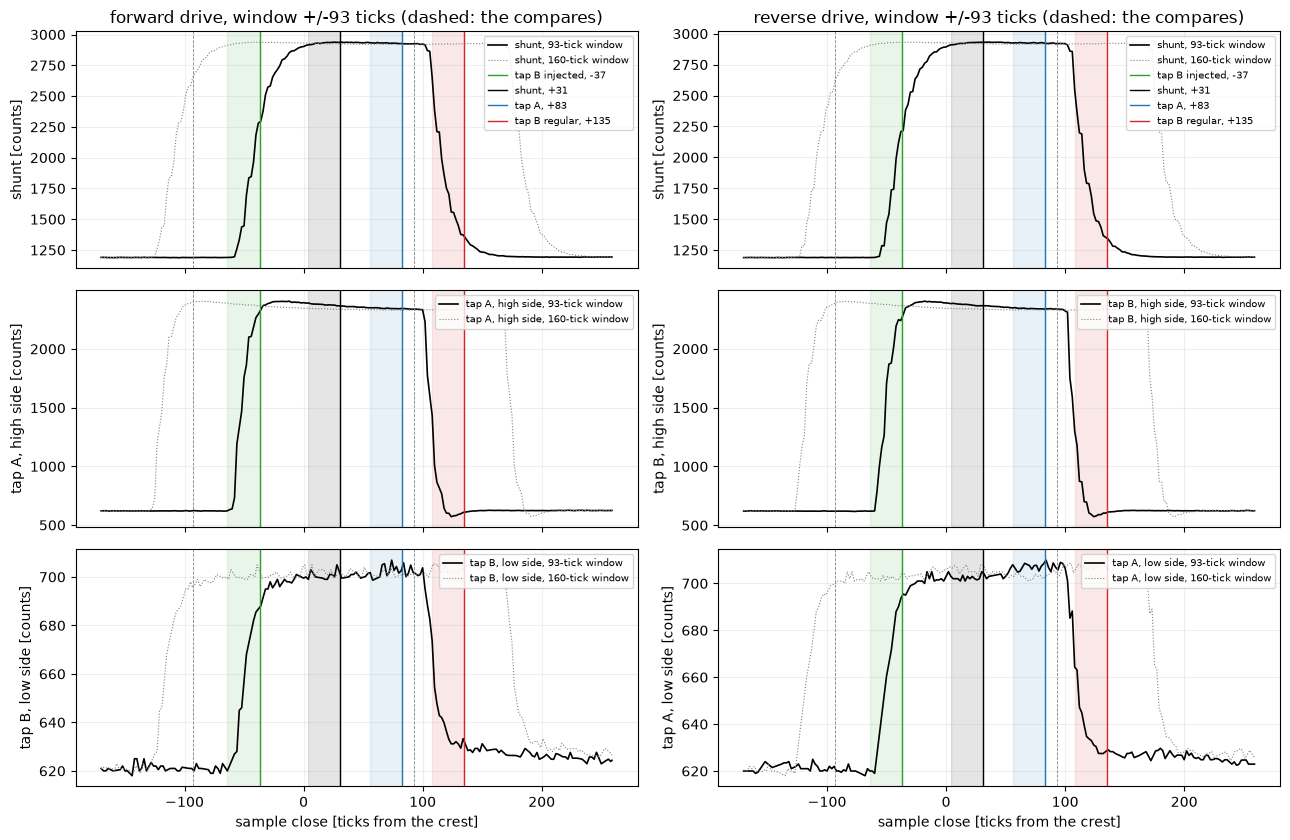

reads at 93  at 30-40%  share of the drive step
dir tap   side sample                                                        
fwd tap A high injected, -37     2313.500   2354.000                    0.977
               slot 1, +83       2343.966   2376.500                    0.981
               slot 2, +135       609.032   2385.750                   -0.007
    tap B low  injected, -37      687.375    705.125                    0.786
               slot 1, +83        704.177    705.875                    0.980
               slot 2, +135       632.062    707.500                    0.118
rev tap A low  injected, -37      694.500    705.500                    0.868
               slot 1, +83        709.181    708.750                    1.005
               slot 2, +135       628.699    710.000                    0.076
    tap B high injected, -37     2265.000   2352.000                    0.950
               slot 1, +83       2338.060   2376.000                    0.978
               slot 2, +135       608.317   2384.500                   -0.008

In [4]:
F_ROOM = {"normal": FOLDS[("room", "off")], "high-speed": FOLDS[("room", "on")]}
H0, H = 456, 93
c = np.arange(-170, 260, 1.0)            # sample close, ticks from the crest
MARK = [(md.CLOSE["injected"], "tap B injected, -37", "tab:green"), (md.CLOSE["shunt"], "shunt, +31", "k"),
        (md.CLOSE["tap A"], "tap A, +83", "tab:blue"), (md.CLOSE["tap B"], "tap B regular, +135", "tab:red")]
fig, axs = plt.subplots(3, 2, figsize=(13, 8.5), sharex=True)
for j, sgn in enumerate((1, -1)):
    roles = (("sh", "shunt"), ("ta", "tap A, high side"), ("tb", "tap B, low side")) if sgn > 0 else \
            (("sh", "shunt"), ("tb", "tap B, high side"), ("ta", "tap A, low side"))
    for i, (s, name) in enumerate(roles):
        st = md.Stream(F_ROOM["normal"], H0, sgn, s)
        ax = axs[i, j]
        ax.plot(c, st.read(H, c), "k-", lw=1.2, label=f"{name}, {H}-tick window")
        ax.plot(c, st.read(160, c), color="grey", lw=0.8, ls=":", label=f"{name}, 160-tick window")
        for t, lab, col in MARK:
            ax.axvspan(t - md.APERTURE_TICKS, t, color=col, alpha=0.10)
            ax.axvline(t, color=col, lw=1, label=lab if i == 0 else None)
        ax.axvline(-H, color="grey", lw=0.6, ls="--")
        ax.axvline(H, color="grey", lw=0.6, ls="--")
        ax.set_ylabel(f"{name} [counts]")
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7, loc="upper right")
    axs[0, j].set_title(("forward" if sgn > 0 else "reverse") + f" drive, window +/-{H} ticks (dashed: the compares)")
    axs[2, j].set_xlabel("sample close [ticks from the crest]")
plt.tight_layout()
plt.show()

# What each sample reads at 93 ticks, against what the same sample reads at the 30-40% rungs.
rows = []
for sgn, roles in ((1, {"tap A": "ta", "tap B": "tb"}), (-1, {"tap A": "ta", "tap B": "tb"})):
    for tap, s in roles.items():
        st = md.Stream(F_ROOM["normal"], H0, sgn, s)
        side = "high" if (tap == "tap A") == (sgn > 0) else "low"
        for when, cc in (("injected, -37", -37), ("slot 1, +83", 83), ("slot 2, +135", 135)):
            ref = np.mean([st.read(h, cc) for h in (360, 480)])
            rows.append({"dir": "fwd" if sgn > 0 else "rev", "tap": tap, "side": side, "sample": when,
                         "reads at 93": st.read(H, cc), "at 30-40%": ref,
                         "share of the drive step": (st.read(H, cc) - st.off) / (ref - st.off)})
display(pd.DataFrame(rows).set_index(["dir", "tap", "side", "sample"]).round(3))

**What you are looking at.** Each stream against the moment a sample of it would close, for a window of
93 ticks (solid) and 160 ticks (dotted). Columns are the two drive directions, rows the shunt, the
high-side tap and the low-side tap. The coloured lines are the four sample instants with their
apertures shaded. The table is what each tap reads at each instant at 93 ticks, as a share of the
drive step it reads at the 30 to 40% rungs (1 is the full step, 0 the brake level).

At 93 ticks the terminals fall about 107 ticks after the crest, so the regular tap B sample at +135
reads the brake, a share of 0 on the high side and 0.1 on the low side. Tap A at +83 is still inside,
at 98% of its step.

The early sample at -37 closes 56 ticks after the ON compare, about 11 ticks after the low-side tap's
half-way point, so the low side is still climbing there and reads 79% of its step forward, 87%
reverse. That sounds bad, but the low side is a small step, about 90 counts against the 1650-count
terminal difference, so the missing part is about 1% of R. That settle is what sets 93 rather than
something lower.

Look at the high side in the 160-tick curve. Right after its rising edge it overshoots the level it
settles to, by about 70 counts on a 1700-count step. That is the grid supply, and section 7 is about
it. The low side barely moves once it is up. So the early sample suits the low side, and only the
low side.

## 4. The model against every ladder

If the folds and the sample instants are the whole story, they should predict each ladder rung's R
error before looking at the ladder. Three scan layouts ran on this board:

| image | high-side tap closes | low-side tap closes |
|---|---|---|
| before | forward A +83, reverse B +135 | forward B +135, reverse A +83 |
| injected, floor93, main | forward A +83, reverse B -37 | forward B -37, reverse A +83 |
| swap | +83 both ways | -37 both ways |

For each, the predicted error is the folded streams read at those instants, the shunt at +31, and the
result held against the same thing at 360 and 480 ticks, exactly the way the ladder is graded. The
prediction uses the room burst set of the ladder's own op-amp mode. The bursts ran the day before the
ladders on the same grid and supply.

148 rungs from 84 ticks up on 16 ladders: median |miss| 0.19 points, 90th percentile 0.68
mean miss per ladder over 96 to 240 ticks [points]:
dir  op-amp      ladder            
fwd  high-speed  new-fwd               0.04
                 old-hson-fwd         -0.01
                 probe-fwd            -0.05
                 unit3-fwd            -0.11
     normal      old-hsoff-fine-fwd   -0.12
                 old-hsoff-fwd        -0.08
                 swap-main-fwd        -0.31
                 swap3-fwd            -0.36
rev  high-speed  new-rev               0.68
                 old-hson-rev          0.08
                 probe-rev             0.40
                 unit3-rev             0.54
     normal      old-hsoff-fine-rev   -0.85
                 old-hsoff-rev        -1.53
                 swap-main-rev         0.13
                 swap3-rev             0.20
the rungs that miss by more than 1 point:


layout      op-amp  dir  measured  predicted  \
ladder             ticks                                                   
old-hsoff-fwd      48       before      normal  fwd   -101.89    -102.98   
                   60       before      normal  fwd    -95.91     -91.28   
old-hsoff-rev      120      before      normal  rev    -70.66     -63.98   
old-hsoff-fine-rev 120      before      normal  rev    -70.56     -63.98   
old-hson-rev       108      before  high-speed  rev   -106.02    -103.83   
probe-fwd          72     injected  high-speed  fwd    -18.30     -30.69   
                   96     injected  high-speed  fwd     -0.30       0.83   
probe-rev          72     injected  high-speed  rev    -99.33     -94.89   
                   84     injected  high-speed  rev    -23.09     -24.42   
new-fwd            60     injected  high-speed  fwd    -93.91     -95.41   
                   72     injected  high-speed  fwd    -18.55     -30.69   
                   96     injected  high-speed  fwd     -0.18       0.83   
new-rev            72     injected  high-speed  rev    -99.16     -94.89   
                   84     injected  high-speed  rev    -22.82     -24.42   
unit3-fwd          72     injected  high-speed  fwd    -18.51     -30.69   
                   96     injected  high-speed  fwd     -0.36       0.83   
unit3-rev          72     injected  high-speed  rev    -99.20     -94.89   
                   84     injected  high-speed  rev    -22.90     -24.42   
swap-main-fwd      60     injected      normal  fwd    -93.75     -90.77   
                   72     injected      normal  fwd    -17.71     -29.55   
swap-main-rev      72     injected      normal  rev    -99.25     -93.60   
swap3-fwd          60         swap      normal  fwd    -93.85     -90.77   
                   72         swap      normal  fwd    -18.02     -29.55   
swap3-rev          60         swap      normal  rev    -92.99     -94.83   
                   72         swap      normal  rev    -17.65     -30.83   

                           miss  
ladder             ticks         
old-hsoff-fwd      48      1.10  
                   60     -4.63  
old-hsoff-rev      120    -6.67  
old-hsoff-fine-rev 120    -6.58  
old-hson-rev       108    -2.19  
probe-fwd          72     12.38  
                   96     -1.13  
probe-rev          72     -4.44  
                   84      1.33  
new-fwd            60      1.51  
                   72     12.14  
                   96     -1.01  
new-rev            72     -4.27  
                   84      1.60  
unit3-fwd          72     12.18  
                   96     -1.19  
unit3-rev          72     -4.31  
                   84      1.52  
swap-main-fwd      60     -2.98  
                   72     11.84  
swap-main-rev      72     -5.65  
swap3-fwd          60     -3.08  
                   72     11.53  
swap3-rev          60      1.84  
                   72     13.18

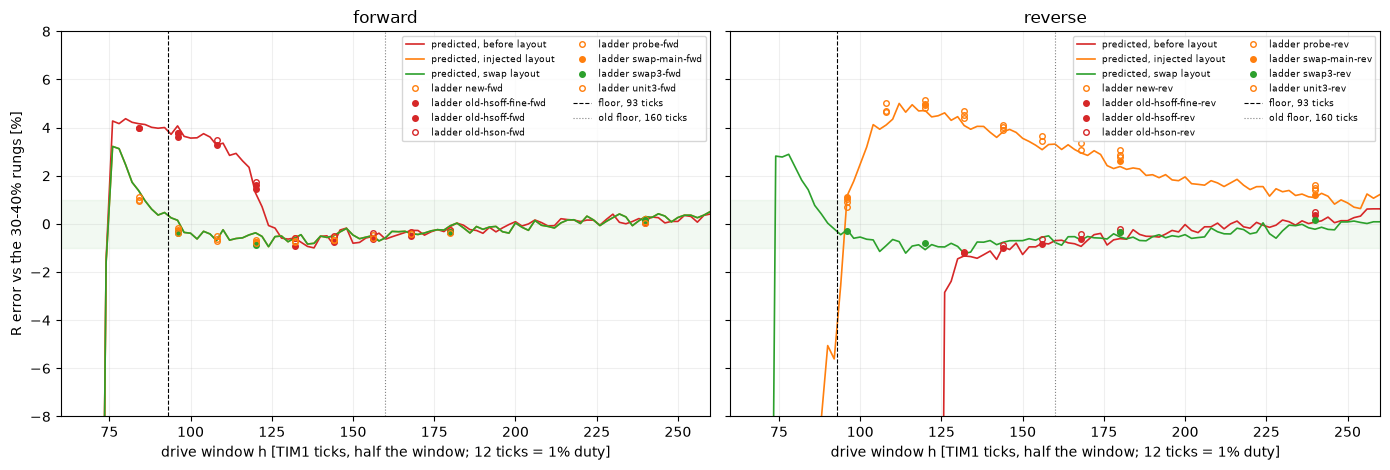

In [5]:
# Scan layouts as (high-side close, low-side close) per direction.
LAYOUT = {"before": {1: (83, 135), -1: (135, 83)},
          "injected": {1: (83, -37), -1: (-37, 83)},
          "swap": {1: (83, -37), -1: (83, -37)}}
LAYOUT_OF = {"before": "before", "probe": "injected", "injected": "injected", "floor93": "injected",
             "main": "injected", "swap": "swap"}
TK = np.arange(60, 492, 2)

rows, curves = [], {}
for l in LAD:
    if l.decay != "slow":
        continue
    lad = l.rungs().set_index("ticks")
    sgn = int(lad.sgn.iloc[0])
    lay = LAYOUT_OF[l.stage]
    f = F_ROOM[l.opamp]
    pred = md.predict_err(f, H0, sgn, *LAYOUT[lay][sgn], lad.index.to_numpy())
    curves[(lay, l.opamp, sgn)] = md.predict_err(f, H0, sgn, *LAYOUT[lay][sgn], TK)
    for h, e in lad.err.items():
        rows.append({"ladder": l.source, "layout": lay, "op-amp": l.opamp, "dir": "fwd" if sgn > 0 else "rev",
                     "ticks": h, "measured": e, "predicted": pred.loc[h]})
PRED = pd.DataFrame(rows)
PRED["miss"] = PRED.measured - PRED.predicted
over = PRED[PRED.ticks >= 84]
print(f"{len(over)} rungs from 84 ticks up on {PRED.ladder.nunique()} ladders: median |miss| "
      f"{over.miss.abs().median():.2f} points, 90th percentile {over.miss.abs().quantile(0.9):.2f}")
band = PRED[(PRED.ticks >= 96) & (PRED.ticks <= 240)]
print("mean miss per ladder over 96 to 240 ticks [points]:")
print(band.groupby(["dir", "op-amp", "ladder"]).miss.mean().round(2).to_string())
print("the rungs that miss by more than 1 point:")
display(PRED[PRED.miss.abs() > 1].round(2).set_index(["ladder", "ticks"]))

fig, axs = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
COLS = {"before": "tab:red", "injected": "tab:orange", "swap": "tab:green"}
for ax, sgn in zip(axs, (1, -1)):
    for (lay, mode, s), cv in curves.items():
        if s == sgn and mode == "normal":
            ax.plot(cv.index, cv, "-", color=COLS[lay], lw=1.2, label=f"predicted, {lay} layout")
    for (lad_name, lay, mode), g in PRED[PRED.dir == ("fwd" if sgn > 0 else "rev")].groupby(["ladder", "layout", "op-amp"]):
        ax.plot(g.ticks, g.measured, "o", ms=4, color=COLS[lay], mfc="none" if mode == "high-speed" else None,
                label=f"ladder {lad_name}")
    ax.axhspan(-1, 1, color="tab:green", alpha=0.06)
    ax.axvline(board.floor_v_ticks, color="k", lw=0.8, ls="--", label=f"floor, {board.floor_v_ticks} ticks")
    ax.axvline(160, color="grey", lw=0.8, ls=":", label="old floor, 160 ticks")
    ax.set_ylim(-8, 8)
    ax.set_xlim(60, 260)
    ax.set_xlabel("drive window h [TIM1 ticks, half the window; 12 ticks = 1% duty]")
    ax.set_title("forward" if sgn > 0 else "reverse")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=6.5, ncol=2)
axs[0].set_ylabel("R error vs the 30-40% rungs [%]")
plt.tight_layout()
plt.show()

**What you are looking at.** Lines are the predicted R error for each scan layout from the normal-mode
fold, dots the ladders (hollow for the high-speed images). The green band is +/-1%, the dashed line the
93-tick floor, the dotted one the old 160. Forward, the injected and swap layouts are the same layout, so the
green line hides the orange one. The table lists every rung the prediction misses by more
than a point.

From 84 ticks up the prediction lands on the ladders with a median miss of 0.19 points, and 90% of
those rungs within 0.68. The per-ladder means over 96 to 240 ticks show two small offsets. The
high-speed images read 0.4 to 0.7 points over the line in reverse, and the two normal-mode images
from the swap afternoon read about 0.3 under it forward. The fold is from the room plateau the day
before, so a few tenths between sessions is about what the supply and the grid would give. The
rungs that miss by more than a point are of two kinds:

- **Rungs where a sample sits on an edge.** The old image's 120-tick reverse rung has tap B's sample
  at +135 right on the falling edge (it reads -70.6% against a predicted -64). The injected images'
  84-tick reverse rung has the high side's early sample on its rising edge, and their 96-tick forward
  rung has the low side's early sample still on its climb. On an edge one tick moves the reading by
  a lot, so a miss of 1 to 7 points there says the edge is where the model puts it to within a tick
  or two.
- **The 72-tick rungs on every image with the injected conversion**, 12 points high forward. Tap A at
  +83 sits on its own falling edge at 72 ticks, and on these images it reads about 200 counts higher
  than on the old image at the same rung (1966 against 1763 counts). The old image's 72-tick rung
  lands on the prediction (-30.4 against -29.5). Something about the injected conversion moved tap A's
  sample by a tick or so. It is under every floor, and I do not know what it is (Open).

Everything else is one picture. Forward, the old layout climbs to +4% at 84 to 108 ticks and the
injected one sits inside about 1% from 84 ticks. Reverse, the old layout collapses below 132 ticks, the
injected layout runs +3 to +5% from 108 to 180 ticks, and the swap layout reads like forward.

## 5. Before: tap B on the brake

Notebook 15 saw the 8% rung read 3.8 to 5.3% high at every plateau. Here is that again, next to
tap B's reading. The tap B the ladder sees at 8% is the brake level, not the drive level. The
share of the low-side drop that goes missing should then be the whole error, so the table works it
out from tap B alone, as tap B's ON level at 15% minus what it read at 8%, over the rung's terminal
difference.

In [6]:
rows = []
for p in ow.Plateau.all(OP):
    lad = p.ladder().set_index("duty")
    ref = lad.loc[[30, 40], "r"].mean()
    err = (lad.r / ref - 1) * 100
    vab8 = lad.loc[8, "va"] - lad.loc[8, "vb"]
    rows.append({"op-amp": "normal" if p.hs == "off" else "high-speed", "plateau": p.plateau,
                 "8% R err": err.loc[8], "10% R err": err.loc[10],
                 "tap B at 6%": lad.loc[6, "vb"], "tap B at 8%": lad.loc[8, "vb"], "tap B at 15%": lad.loc[15, "vb"],
                 "missing low side, % of vab": (lad.loc[15, "vb"] - lad.loc[8, "vb"]) / vab8 * 100})
display(pd.DataFrame(rows).set_index(["op-amp", "plateau"]).round(2))

8% R err  10% R err  tap B at 6%  tap B at 8%  \
op-amp     plateau                                                  
normal     room         3.77       1.64       611.97       615.17   
high-speed room         3.84       1.70       612.29       615.46   
           43           4.46       2.32       613.01       616.15   
normal     43           4.62       2.24       612.74       615.93   
           59           5.29       2.59       613.39       616.68   
high-speed 59           5.16       2.61       613.41       616.78   
normal     room2        3.96       1.76       612.24       615.44   
high-speed room2        3.94       1.86       612.42       615.69   

                    tap B at 15%  missing low side, % of vab  
op-amp     plateau                                            
normal     room           695.41                        4.67  
high-speed room           695.76                        4.67  
           43             699.61                        4.82  
normal     43             699.44                        4.82  
           59             704.60                        5.03  
high-speed 59             704.82                        5.04  
normal     room2          696.06                        4.69  
high-speed room2          696.40                        4.70

**What you are looking at.** One row per plateau and mode of notebook 15's ladders. Tap B at 6% and
8% sits at 612 to 617 counts, the brake level, and at 15% it reads its drive level, 695 to 705. The
last column is the share of the terminal difference that the brake reading leaves out, 4.7 to 5.0%,
against R errors of 3.8 to 5.3%. Both grow with the board in the same order. They do not match to
the tenth, and they should not quite. The column assumes tap B would have read its 15% level at 8%,
and the probe ladder below shows an 8% window's low side sits about 13 counts under that, which is
most of the gap at room. The size and the trend say the old floor's error is tap B missing the
window.

The cleanest proof is the probe image. It put tap B on the injected conversion and still streamed the
regular scan's tap B in a spare column, so one ladder carries both samples of the same terminal, row
by row, under the same current and the same tap A.

In [7]:
rows = []
for name in ("probe-fwd", "probe-rev"):
    l = BY[name]
    inj = l.rungs().set_index("ticks")                  # tap B from the injected conversion
    reg = l.rungs(tap_b="ntc_raw").set_index("ticks")   # tap B from the regular scan, same rows
    for h in inj.index:
        rows.append({"dir": "fwd" if inj.sgn.iloc[0] > 0 else "rev", "ticks": h, "duty %": abs(inj.duty.loc[h]),
                     "tap B injected": inj.lo.loc[h] if inj.sgn.iloc[0] > 0 else inj.hi.loc[h],
                     "tap B regular": reg.lo.loc[h] if reg.sgn.iloc[0] > 0 else reg.hi.loc[h],
                     "R err, injected B": inj.err.loc[h], "R err, regular B": reg.err.loc[h]})
PROBE = pd.DataFrame(rows).set_index(["dir", "ticks"])
display(PROBE.round(2))

duty %  tap B injected  tap B regular  R err, injected B  \
dir ticks                                                             
fwd 72          6          614.37         612.42             -18.30   
    84          7          660.77         613.94               1.00   
    96          8          680.58         615.38              -0.30   
    108         9          686.27         621.49              -0.63   
    120        10          689.23         655.55              -0.75   
    132        11          690.56         691.56              -0.72   
    144        12          691.32         692.24              -0.65   
    156        13          692.15         693.01              -0.56   
    168        14          692.79         693.91              -0.44   
    180        15          693.51         694.78              -0.35   
    240        20          696.90         698.93               0.10   
    360        30          706.04         708.20               0.16   
    480        40          714.64         716.15              -0.16   
rev 72          6          690.64         607.34             -99.33   
    84          7         1947.14         603.82             -23.09   
    96          8         2334.56         585.03               0.71   
    108         9         2396.17         611.11               4.66   
    120        10         2395.90        1296.47               4.82   
    132        11         2386.44        2324.36               4.40   
    144        12         2375.79        2326.09               3.89   
    156        13         2366.27        2327.75               3.46   
    168        14         2358.69        2329.86               3.08   
    180        15         2351.75        2332.14               2.76   
    240        20         2333.05        2346.82               1.42   
    360        30         2343.47        2377.62               0.07   
    480        40         2375.49        2400.45              -0.07   

           R err, regular B  
dir ticks                    
fwd 72               -18.10  
    84                 3.93  
    96                 3.74  
    108                3.40  
    120                1.40  
    132               -0.68  
    144               -0.60  
    156               -0.51  
    168               -0.40  
    180               -0.32  
    240                0.09  
    360                0.14  
    480               -0.14  
rev 72              -104.35  
    84              -105.25  
    96              -106.41  
    108             -104.89  
    120              -63.51  
    132               -1.21  
    144               -0.97  
    156               -0.71  
    168               -0.50  
    180               -0.25  
    240                0.47  
    360                0.35  
    480               -0.35

**What you are looking at.** The probe ladders, both directions. Each row is one rung with the two tap
B samples taken in the same PWM periods.

Forward, tap B is the low side. The regular sample reads 612 to 622 counts up to 108 ticks, the brake,
and R comes out 3.4 to 3.9% high. The injected sample reads 661 to 686, the drive level, and R sits
at -0.3 to -0.6% from 96 ticks. At 132 ticks and above the two agree within 0.05 points. Reverse is
the same story for the regular sample, worse, because tap B is the high side there and the whole
drive voltage goes missing (-104 to -106%). The injected sample is good from 96 ticks in reverse too, but it
reads high. That is section 7.

## 6. Steps 1 and 2: the early tap B and the 93-tick floor

The injected image and the floor93 image only differ in the published floor, so
their forward ladders should agree rung for rung. The floor93 image also streamed the firmware's own
terminal difference `vdiff`, which is what the observer, the resistance fit and calibration actually
read. Under its floor `vdiff` holds the last valid value, so a held rung is one constant for 3000
samples and a live one moves.

In [8]:
FWD = pd.DataFrame({
    "before, normal": BY["old-hsoff-fine-fwd"].rungs().set_index("ticks").err,
    "injected": BY["new-fwd"].rungs().set_index("ticks").err,
    "floor93, crest taps": BY["unit3-fwd"].rungs().set_index("ticks").err,
    "floor93, firmware vdiff": BY["unit3-fwd"].vdiff_rungs().set_index("ticks").err,
})
FWD = FWD[(FWD.index >= 72) & (FWD.index <= 180)]
print("forward R error vs the 30-40% rungs [%]:")
display(FWD.round(2))

rows = []
for name in ("unit3-fwd", "unit3-rev", "unit3-fast-fwd"):
    v = BY[name].vdiff_rungs()
    for r in v.itertuples():
        rows.append({"ladder": name, "decay": BY[name].decay, "ticks": r.ticks, "vdiff": "live" if r.live else "held",
                     "distinct values": r.distinct})
V = pd.DataFrame(rows)
display(V.pivot_table(index="ticks", columns="ladder", values="vdiff", aggfunc="first"))

# What the floor93 image publishes, read back over the bus under each decay mode.
fl = (DS.path / "readback" / "floors.txt").read_text()
print(fl.strip())
pub = {"slow": int(re.search(r"decay slow: window_v_floor_q15 = (\d+)", fl).group(1)),
       "fast": int(re.search(r"decay fast: window_v_floor_q15 = (\d+)", fl).group(1)),
       "current": int(re.search(r"window_floor_q15 = (\d+)", fl).group(1))}
expect = {"slow": md.floor_q15(board.floor_v_ticks), "fast": md.floor_q15(160), "current": md.floor_q15(board.floor_i_ticks)}
print("published against floor_duty of the board's ticks:", {k: (pub[k], expect[k]) for k in pub})
assert pub == expect

forward R error vs the 30-40% rungs [%]:


,"before, normal",injected,"floor93, crest taps","floor93, firmware vdiff"
ticks,,,,
72,-30.35,-18.55,-18.51,NaN
84,3.97,1.11,0.94,NaN
96,3.62,-0.18,-0.36,-0.36
108,3.26,-0.51,-0.72,-0.72
120,1.47,-0.68,-0.80,-0.80
132,-0.90,-0.59,-0.74,-0.74
144,-0.76,-0.54,-0.66,-0.66
156,-0.61,-0.46,NaN,NaN
168,-0.51,-0.40,NaN,NaN


ladder,unit3-fast-fwd,unit3-fwd,unit3-rev
ticks,,,
72,NaN,held,held
84,NaN,held,held
96,held,live,live
108,NaN,live,live
120,held,live,live
132,NaN,live,live
144,held,live,live
156,held,NaN,NaN
168,live,NaN,NaN


unit3 image, torque off, RAM only:
v_window_min_ticks = 93
window_floor_q15 = 1734
openloop_decay slow: window_v_floor_q15 = 2526 (93 ticks)
openloop_decay fast: window_v_floor_q15 = 4356 (160 ticks)
back to slow: 2526
published against floor_duty of the board's ticks: {'slow': (2526, 2526), 'fast': (4356, 4356), 'current': (1734, 1734)}


**What you are looking at.** First, forward R error at each rung from 72 to 180 ticks: the old image,
the injected image, and the floor93 image read two ways (the streamed taps, and the firmware's own
`vdiff`). Then whether `vdiff` was live or held at each rung of the floor93 ladders. Last, the floors
the servo published.

Forward, the early tap B takes the error from +3.6% to -0.2% at 96 ticks and from +1.5% to -0.7% at
120. At 84 ticks the crest taps read +0.9 to +1.1%, and from 96 to 180 every rung sits between -0.8% and
-0.2%. The firmware's `vdiff` gives exactly the crest taps' R wherever it is live. It is held at 72 and
84 ticks and live from 96, on the two sides of the 93-tick floor. Reverse goes live at the
same place. Under Fast decay the terminals are sampled on the trough scan, whose tap B closes 135 ticks
into the window, so `vdiff` stays held through 156 ticks and goes live at 168, on either side of the
160 it keeps.

The servo publishes 2526 under Slow and 4356 under Fast, which is `floor_duty` of 93 and 160 ticks to
the count. A host planning a terminal-voltage drive reads 7.7% now, not 13.3%.

The 84-tick rung (7%) reads +0.9 to +1.1%, right on the 1% line, and section 3 says why: the low
side's early sample is still climbing there. 93 sits about a rung's width above it.

## 7. Step 3: reverse drive and the tap swap

With tap B early in both directions, reverse drive samples the **high-side** terminal early. The
ladders say that reads 3 to 5% high from 108 to 180 ticks. Section 3's plot already shows why. Here is
the high-side tap over the whole window from the 38% burst set, against time from the ON compare, with
the two sample instants a reverse rung uses.

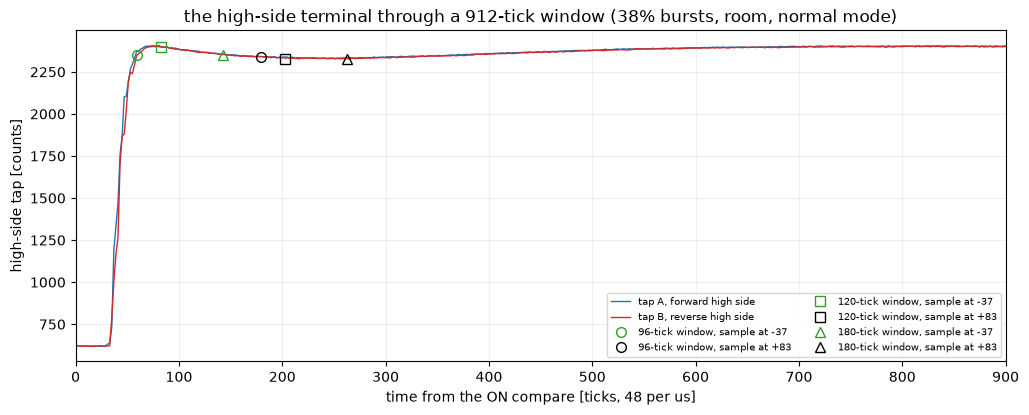

,high side at -37,high side at +83,"early minus late, % of vab","main reverse ladder, R err %"
ticks,,,,
96,2348.0,2340.00,0.49,1.13
120,2399.5,2327.66,4.43,4.97
180,2353.0,2327.00,1.61,2.59
240,2331.5,2339.00,-0.46,1.19


,high side [counts],shunt over its zero [counts]
ticks after the ON compare,,
80,2400.2,1636.0
120,2365.5,1739.2
160,2343.0,1734.0
240,2331.2,1724.0
400,2356.2,1752.5
700,2397.8,1804.5
880,2398.5,1805.0


In [9]:
fig, ax = plt.subplots(figsize=(12, 4.3))
for sgn, s, lab, col in ((1, "ta", "tap A, forward high side", "tab:blue"), (-1, "tb", "tap B, reverse high side", "tab:red")):
    st = md.Stream(F_ROOM["normal"], H0, sgn, s)
    m = (st.x > 0) & (st.x < 2 * H0)
    ax.plot(st.x[m], st.p[m], "-", color=col, lw=1, label=lab)
for h, mk in ((96, "o"), (120, "s"), (180, "^")):
    for cc, col in ((-37, "tab:green"), (83, "k")):
        ax.plot(h + cc, md.Stream(F_ROOM["normal"], H0, -1, "tb").read(h, cc), mk, color=col, ms=7, mfc="none",
                label=f"{h}-tick window, sample at {cc:+d}")
ax.set_xlim(0, 900)
ax.set_xlabel("time from the ON compare [ticks, 48 per us]")
ax.set_ylabel("high-side tap [counts]")
ax.set_title("the high-side terminal through a 912-tick window (38% bursts, room, normal mode)")
ax.grid(alpha=0.2)
ax.legend(fontsize=7, ncol=2)
plt.show()

# The reverse error the high side alone explains: its early sample minus its late one, over the drive step.
hs_rev = md.Stream(F_ROOM["normal"], H0, -1, "tb")   # reverse high side
ls_rev = md.Stream(F_ROOM["normal"], H0, -1, "ta")   # reverse low side
rows = []
for h in (96, 120, 180, 240):
    vab = hs_rev.read(h, 83) - ls_rev.read(h, 83)
    rows.append({"ticks": h, "high side at -37": hs_rev.read(h, -37), "high side at +83": hs_rev.read(h, 83),
                 "early minus late, % of vab": (hs_rev.read(h, -37) - hs_rev.read(h, 83)) / vab * 100,
                 "main reverse ladder, R err %": BY["swap-main-rev"].rungs().set_index("ticks").err.get(h, np.nan)})
display(pd.DataFrame(rows).set_index("ticks").round(2))

# The shunt through the same window: if the high side moves because the rail moves, the current
# through the grid moves with it.
sh_rev = md.Stream(F_ROOM["normal"], H0, -1, "sh")
taus = [80, 120, 160, 240, 400, 700, 880]
display(pd.DataFrame({"high side [counts]": np.interp(taus, hs_rev.x, hs_rev.p),
                      "shunt over its zero [counts]": np.interp(taus, sh_rev.x, sh_rev.p) - sh_rev.off},
                     index=pd.Index(taus, name="ticks after the ON compare")).round(1))

**What you are looking at.** The high-side tap from the moment the ON compare fires to the end of a
long window, forward and reverse on top of each other, with the samples a reverse rung takes at 96,
120 and 180 ticks. The table is the early sample minus the late one as a share of the drive step.

The high side jumps to about 2400 counts as the terminal rises, then sags to about 2330 over the next
150 ticks, then climbs back to about 2400 by 700. The second table has the shunt at the same moments,
and from 120 ticks on it follows the same dip and recovery (at 80 it is still on the op-amp's own
climb, section 8). A current through a fixed resistor that dips with the
terminal voltage means the voltage across the load really dipped, so this is the supply rail, not the
tap. On the grid the current steps to 1.7 A in one edge, the bench
supply and the board's capacitors take a moment to catch up, and the rail sags and recovers. A
sample 30 to 100 ticks after the edge sees the rail before the sag. A sample at +83 sees it in the
sag, together with the current at +31. So the early high-side sample reads high against everything
else. The high side alone gives 4.4 of the 5.0 points the main ladder reads at 120 ticks, and 1.6 of
2.6 at 180. The section 4 model, which also puts the shunt and the low side at their own instants,
gives 4.7 and 2.4.

The low side is a small voltage (the current through the low switch and the shunt, about 330 mV)
and it barely moves after its edge. The fix is to never sample the high side early. The swap image
samples whichever tap is the low side at -37 and the high side at +83, so reverse reads the same way
forward does.

In [10]:
REV = pd.DataFrame({
    "main, reverse": BY["swap-main-rev"].rungs().set_index("ticks").err,
    "swap, reverse": BY["swap3-rev"].rungs().set_index("ticks").err,
    "swap, forward": BY["swap3-fwd"].rungs().set_index("ticks").err,
    "main, forward": BY["swap-main-fwd"].rungs().set_index("ticks").err,
})
REV["swap, rev minus fwd"] = REV["swap, reverse"] - REV["swap, forward"]
display(REV[REV.index >= 72].round(2))

,"main, reverse","swap, reverse","swap, forward","main, forward","swap, rev minus fwd"
ticks,,,,,
72,-99.25,-17.65,-18.02,-17.71,0.37
96,1.13,-0.29,-0.38,-0.27,0.09
120,4.97,-0.80,-0.86,-0.75,0.06
180,2.59,-0.35,-0.34,-0.32,-0.01
240,1.19,0.16,0.16,0.13,-0.01
360,0.01,0.27,0.19,0.24,0.08
480,-0.01,-0.27,-0.19,-0.24,-0.08


**What you are looking at.** R error per rung on the main image (tap B early in both directions) and
the swap image, both in normal mode on the same afternoon.

Main reads +1.1%, +5.0%, +2.6% and +1.2% in reverse at 96, 120, 180 and 240 ticks. The swap image
reads -0.3%, -0.8%, -0.4% and +0.2%, and reverse sits within 0.1 points of forward at every one of
those rungs. Forward does not change with the swap, as it should not, since forward already sampled
the low side early. The op-amp mode had nothing to do with the reverse error. The normal-mode main
image shows it the same as the high-speed images did.

### The frame that straddles a flip

The swap rewrites the injected channel and the two regular tap slots when the drive direction changes,
in the gap after the crest scan. The frame sampled across that change is mapped by the old order. That
is safe only if the firmware never uses its terminals, so here are the rows around each flip in the
flip ladder (+10%, -10%, +10%, -10%), until the duty is back over the 93-tick floor.

In [11]:
fl = md.Ladder.flip(DS)
s = fl.frame
rows = []
for seg in (2, 3, 4):
    g = s[s.seg == seg].reset_index(drop=True)
    k0 = int(np.flatnonzero(np.sign(g.duty_q15) == np.sign(g.cmd_duty_q15))[0])   # first row in the new direction
    held = g[(g.duty_q15 == g.cmd_duty_q15)].iloc[40:]                            # the settled rung
    hi_col, lo_col = ("vmotor_a", "vmotor_b") if g.cmd_duty_q15.iloc[0] > 0 else ("vmotor_b", "vmotor_a")
    for k in range(k0, len(g)):
        r = g.iloc[k]
        gap = k > 0 and g.tick.iloc[k] - g.tick.iloc[k - 1] != 1        # a dropped TEL row right before this one
        rows.append({"flip to": "fwd" if r.cmd_duty_q15 > 0 else "rev", "row": k - k0, "duty_q15": r.duty_q15,
                     "ticks": r.ticks, "over 93": r.ticks >= board.floor_v_ticks, "high-side tap": r[hi_col],
                     "low-side tap": r[lo_col], "row dropped before": gap, "settled high side": f"{held[hi_col].min()}..{held[hi_col].max()}"})
        if r.ticks >= board.floor_v_ticks:
            break
FLIP = pd.DataFrame(rows).set_index(["flip to", "row"])
display(FLIP)
dropped = re.search(r"dropped (\d+) TEL rows", (DS.path / "flip/capture-1/sweep.log").read_text())
print("TEL rows the servo dropped in this capture:", dropped.group(1) if dropped else 0)

duty_q15  ticks  over 93  high-side tap  low-side tap  \
flip to row                                                          
rev     0     -1862.0   68.0    False          690.0         645.0   
        1     -1990.0   73.0    False         1306.0         611.0   
        2     -2118.0   78.0    False         2341.0         616.0   
        3     -2246.0   82.0    False         2339.0         635.0   
        4     -2374.0   87.0    False         2338.0         652.0   
        5     -2502.0   92.0    False         2334.0         669.0   
        6     -2630.0   96.0     True         2333.0         680.0   
fwd     0      1862.0   68.0    False          693.0         648.0   
        1      1990.0   73.0    False         1291.0         612.0   
        2      2118.0   78.0    False         2341.0         619.0   
        3      2246.0   82.0    False         2340.0         639.0   
        4      2374.0   87.0    False         2338.0         655.0   
        5      2502.0   92.0    False         2337.0         670.0   
        6      2630.0   96.0     True         2334.0         678.0   
rev     0     -1862.0   68.0    False          691.0         645.0   
        1     -1990.0   73.0    False         1314.0         611.0   
        2     -2118.0   78.0    False         2341.0         615.0   
        3     -2246.0   82.0    False         2339.0         636.0   
        4     -2374.0   87.0    False         2336.0         653.0   
        5     -2502.0   92.0    False         2334.0         668.0   
        6     -2630.0   96.0     True         2333.0         679.0   

             row dropped before settled high side  
flip to row                                        
rev     0                 False        2323..2330  
        1                 False        2323..2330  
        2                 False        2323..2330  
        3                 False        2323..2330  
        4                 False        2323..2330  
        5                 False        2323..2330  
        6                 False        2323..2330  
fwd     0                 False        2325..2331  
        1                 False        2325..2331  
        2                 False        2325..2331  
        3                 False        2325..2331  
        4                 False        2325..2331  
        5                 False        2325..2331  
        6                 False        2325..2331  
rev     0                 False        2323..2329  
        1                 False        2323..2329  
        2                 False        2323..2329  
        3                 False        2323..2329  
        4                 False        2323..2329  
        5                 False        2323..2329  
        6                 False        2323..2329

TEL rows the servo dropped in this capture: 6


**What you are looking at.** For each of the three flips, the rows from the first one in the new
direction until the window is back over 93 ticks, with the tap on each side and the range the high side
holds once the rung has settled.

After a flip the duty restarts at 1862 (68 ticks), just over the current floor, and climbs 128 counts
a row, so it takes six rows to get back over 93 ticks. Row 0 is the straddle frame. Its taps read 690
and 645 counts, both near the low levels, so it carries neither direction's drive. Row 1 is a 73-tick
window with the high side half way up its edge. From row 2 the high side is up, 3 to 15 counts over
the range the settled 120-tick rung holds, which is the shorter window sitting earlier on the rail's
dip (section 7). All six rows are under the floor, so `vdiff` holds through them and none of them
feeds the observer or a fit. The first row over the floor reads 2333 to 2334, within 4 counts of the
settled range. No TEL row was dropped inside these runs, the taps kept their names through every
flip, and nothing says the scan rotated.

## 8. The current chain

The current has its own floor, 64 ticks (5.3%), and it is set by a different thing. The shunt sample
closes 31 ticks after the crest, which is inside any window the terminals can use. What limits it is
the op-amp, which takes time to climb to its plateau after the ON edge. The firmware multiplies a short
window's reading by a settle gain per 8-tick band to make up the shortfall (`i_settle_gain` in the
dev-v006 board file). That table was measured with the op-amp in high-speed mode, before the switch to normal mode.

To see the climb against something that does not climb, the shunt is divided by the terminal
difference at the same instant. The taps settle within about 20 ticks of their edge, so the ratio is the
op-amp's step response on its own. It is normalized to its own late-window value, from 250 ticks after
the ON compare to the end of the window, in every burst set that reads both taps (four plateaus, both
directions, 300 and 456 ticks wide).

shipped settle gain: from 40 ticks, 21 bands, 1.1334 .. 1.0005


raw             with table            
                mean   min   max       mean   min   max
op-amp     h                                           
high-speed 56  -4.08 -4.48 -3.62       0.52  0.11  1.01
           60  -3.53 -4.00 -2.94       1.10  0.61  1.72
           64  -3.04 -3.67 -2.42       0.36 -0.29  1.01
           68  -2.66 -2.98 -2.07       0.76  0.42  1.37
           72  -2.39 -2.90 -1.80       0.22 -0.30  0.82
           76  -2.11 -2.54 -1.57       0.51  0.07  1.06
           80  -1.89 -2.32 -1.17       0.21 -0.23  0.95
           88  -1.60 -2.06 -0.82       0.22 -0.25  1.02
           96  -1.32 -1.66 -0.62       0.16 -0.19  0.87
           120 -0.76 -0.94 -0.52       0.25  0.07  0.50
           160 -0.54 -0.99 -0.31      -0.14 -0.59  0.09
normal     56  -7.00 -7.92 -5.94      -2.54 -3.50 -1.42
           60  -5.78 -6.70 -4.88      -1.25 -2.22 -0.31
           64  -4.75 -5.53 -4.00      -1.40 -2.22 -0.64
           68  -4.00 -4.59 -3.26      -0.63 -1.24  0.14
           72  -3.34 -3.85 -2.80      -0.76 -1.28 -0.21
           76  -2.89 -3.30 -2.36      -0.30 -0.72  0.25
           80  -2.50 -3.07 -2.06      -0.41 -0.99  0.04
           88  -1.95 -2.39 -1.61      -0.13 -0.58  0.21
           96  -1.58 -1.93 -1.17      -0.11 -0.46  0.32
           120 -0.86 -1.13 -0.59       0.16 -0.12  0.43
           160 -0.47 -0.76 -0.18      -0.07 -0.36  0.22

normal minus high-speed, mean raw [points]: {64: -1.7, 68: -1.34, 72: -0.95, 80: -0.61, 96: -0.26}


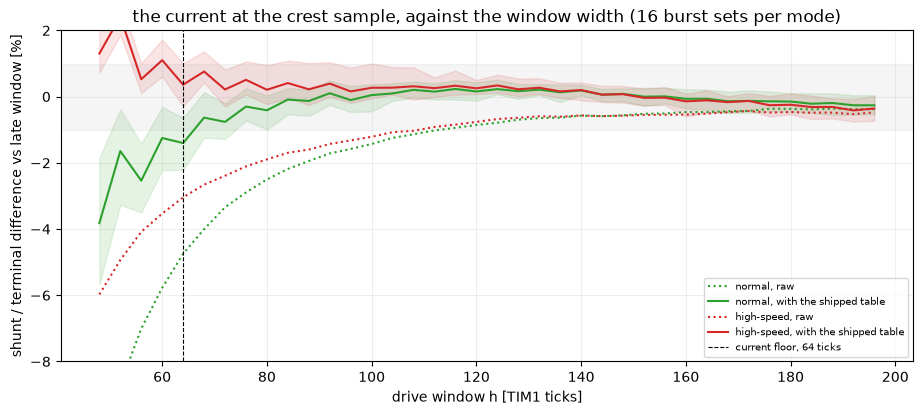

In [12]:
TABLE = md.settle_gain()                 # (start_ticks, q15 per 8-tick band), as the board file ships it
print(f"shipped settle gain: from {TABLE[0]} ticks, {len(TABLE[1])} bands, "
      f"{TABLE[1][0] / 32768:.4f} .. {TABLE[1][-1] / 32768:.4f}")
rows = []
for (pl, hs), f in FOLDS.items():
    for h0 in (456, 300):
        for sgn in (1, -1):
            hi, lo = ("ta", "tb") if sgn > 0 else ("tb", "ta")
            pr = {s: md.profile(f[(h0, sgn, s)][0] + h0, f[(h0, sgn, s)][1], -200, 2 * h0 + 300, 4)
                  for s in ("sh", hi, lo)}
            x = pr["sh"][0]
            zero = np.median(pr["sh"][1][x < -60])                      # the shunt before the window
            with np.errstate(divide="ignore", invalid="ignore"):      # the difference is 0 outside the window
                ratio = (pr["sh"][1] - zero) / (pr[hi][1] - pr[lo][1])  # current over the terminal difference
            ratio = ratio / np.median(ratio[(x > 250) & (x < 2 * h0 - 60)])
            for h in range(48, 200, 4):
                v = np.interp(h + md.CLOSE["shunt"], x, ratio)          # a window h samples it h + 31 after the ON edge
                rows.append({"op-amp": "normal" if hs == "off" else "high-speed", "set": (pl, h0, sgn), "h": h,
                             "raw": (v - 1) * 100, "with table": (v * md.settle_gain_at(h, TABLE) - 1) * 100})
ST = pd.DataFrame(rows)
SUM = ST.groupby(["op-amp", "h"])[["raw", "with table"]].agg(["mean", "min", "max"])
show_h = [56, 60, 64, 68, 72, 76, 80, 88, 96, 120, 160]
display(SUM.loc[(slice(None), show_h), :].round(2))
mode_gap = (SUM.loc["normal", ("raw", "mean")] - SUM.loc["high-speed", ("raw", "mean")])
print("normal minus high-speed, mean raw [points]:", mode_gap.loc[[64, 68, 72, 80, 96]].round(2).to_dict())

fig, ax = plt.subplots(figsize=(11, 4.3))
for mode, col in (("normal", "tab:green"), ("high-speed", "tab:red")):
    g = SUM.loc[mode]
    ax.plot(g.index, g[("raw", "mean")], ":", color=col, label=f"{mode}, raw")
    ax.plot(g.index, g[("with table", "mean")], "-", color=col, label=f"{mode}, with the shipped table")
    ax.fill_between(g.index, g[("with table", "min")], g[("with table", "max")], color=col, alpha=0.12)
ax.axhspan(-1, 1, color="grey", alpha=0.08)
ax.axvline(board.floor_i_ticks, color="k", ls="--", lw=0.8, label=f"current floor, {board.floor_i_ticks} ticks")
ax.set_ylim(-8, 2)
ax.set_xlabel("drive window h [TIM1 ticks]")
ax.set_ylabel("shunt / terminal difference vs late window [%]")
ax.set_title("the current at the crest sample, against the window width (16 burst sets per mode)")
ax.grid(alpha=0.2)
ax.legend(fontsize=7)
plt.show()

**The table this cell reads has changed.** `minduty.settle_gain` parses `i_settle_gain` from the
board file as it ships, so the cell above follows the firmware. The paragraphs below were written
against the table measured in high-speed mode, top band 1.0725. The board file now ships a
different table, top band 1.1334, and the output above is that table's. Normal mode reads 1.40% low
at 64 ticks (worst set 2.22%), 0.63% at 68 and 0.76% at 72, and high-speed mode reads 0.2 to 1.1%
high below 96 ticks. The numbers below are the older table's and stay as written. Open carries the
mismatch.

**What you are looking at.** The current the crest sample reads at each window width, as a shortfall
against the late window, raw and with the shipped settle gain applied, for each op-amp mode (the
shaded band is the range over the 16 burst sets). The table has the numbers at a few widths.

In high-speed mode, the mode the table was measured in, the table brings the 64-tick floor to -0.65%
by this yardstick. The yardstick is not the table's own reference (that was a grid ladder's
rungs, per the board file), so a few tenths either way is the reference, not the op-amp. In normal mode the op-amp is
slower. Raw it is 4.8% short at 64 ticks against high-speed's 3.0%, and with the shipped table it reads
2.4% low at 64 (worst set 3.2%), 1.6% at 68 and 1.3% at 72, and it is inside 1% from about 76 ticks.

So the 64-tick floor still holds the 3% it was set for (notebook 10 sec 8), with nothing to spare in
the worst set. The shipped table rescales its low bands by the ratio between the two modes, from the same bursts, and that rescale quotes 1.3 / 1.0 / 0.8% low at 64 / 68 / 72 ticks with the old table. My mode gap
here, normal minus high-speed raw, is 1.7 / 1.3 / 1.0 points. The two estimates use different reference windows and bin the edge
differently, and this notebook does not settle which is closer (Open). Either way it is the op-amp, a
gain question, and the terminal floor does not depend on it.

## 9. What this decides

**Floors on rev 2A, as of this notebook:**

| path | floor | duty | what sets it |
|---|---|---|---|
| current (`i_window_min_ticks`) | 64 ticks | 5.3% | the op-amp's settle, 3% with the settle gain (section 8) |
| terminals, Slow decay (`v_window_min_ticks`) | 93 ticks | 7.7% | tap A at +83 inside the window, the early sample settled (sections 4 and 6) |
| terminals, Fast decay (`v_trough_window_min_ticks`) | 160 ticks | 13.3% | the trough scan's tap B still closes 135 ticks into the window |
| back-EMF observer (`bemf_window_min_ticks`) | 160 ticks | 13.3% | the drive pulse is about 27 ticks short of its width (section 2) |

93 holds in both directions with the tap swap, which ships. Without it, reverse on the main image still reads
1.2% high at 240 ticks (20% duty), so a reverse-only floor would have had to sit near 20%. That is
why the fix is the swap and not a floor per direction.

**The averaging taps are not needed.** The plan going in had a second option, 100 nF on each tap so the
taps read a period average, which would have moved the floor to about 5% with no firmware change. It
changes what the taps mean (a period average instead of the drive level, so every consumer needs the
real ON time or a model of the switch drops) and it adds a lag of a couple of periods to the fast
loop. The firmware fix reaches 93 ticks without either. The caps stay off.

**The MG90 is not measured here.** The grid is the worst case for the rail, because its current
steps on in one edge, so none of the numbers above are MG90 numbers. Open has the MG90 ladder on
the swap image and what it has to show.

## Caveats

- **One board, one grid, one supply.** Every ladder ran on board #1 with the 4.2 ohm grid and the
  DPS-150 at 7.9 V. The edges and the sample instants are timer facts and should carry over. The
  size of the reverse error is a supply fact and will not.
- **The grid is not a motor.** It has no inductance, so its current steps to 1.7 A at every edge and
  pulls the rail down hard. The grid also warms through a ladder (notebook 15 sec 3). A motor's current
  ramps through its winding and is 5 to 20 times smaller at these duties, so the rail sag should be much
  smaller. That is a prediction, and the MG90 ladder is what tests it.
- **Three of the images ran the op-amp in high-speed mode.** The probe, injected and floor93 images were built before the switch to normal mode. Tap timing does not care (notebook 15 sec 4, and section 4 here), but their current
  readings are not comparable with the normal-mode images to better than a few tenths, so each table
  holds a ladder only against its own 30 to 40% rungs.
- **The prediction uses bursts from the day before.** Same grid, same supply, board at room both times,
  but not the same session. It is good to about half a point, which is what section 4 can claim.
- **The 30 to 40% reference is not a truth.** It is where every sample is far from an edge. Notebook 15
  graded the chain itself against a meter.
- **Six TEL rows were dropped in the flip capture.** None of them fall in the rows section 7 looks at
  (those come from a gap-free run of ticks), but the loss itself is a TEL staging issue in the firmware, not in this analysis.

## Open

- **Tap A at 72 ticks on the images with the injected conversion (section 4).** It reads about 200 counts
  higher than on the old image, at a rung where tap A's sample sits on its own falling edge. Candidates:
  (a) the injected conversion delays the regular scan's start by a clock or two, (b) the injected
  conversion's charge on the shared sample capacitor shifts the next tap reading. A fold of tap A from
  bursts on the injected image separates them. (a) moves tap A's whole edge by the same few ticks at
  every width. (b) leaves the edge where it is and shows only in the regular scan's first tap slot. It
  is under every floor, so nothing waits on it.
- **Small session offsets against the prediction (section 4).** The high-speed images read 0.4 to 0.7
  points over the line in reverse, and the swap-afternoon normal-mode images about 0.3 under it
  forward, while the rest sit within 0.15. Candidates: (a) the supply's dip after the edge differed a
  little between sessions (the grid's temperature, the supply's own state), (b) the op-amp mode changes
  how the current follows the dip. A burst set and a ladder in the same session, in each mode,
  separate them. (a) predicts each session's burst set moves with its ladder and the offset vanishes.
  (b) predicts a fixed offset per mode.
- **The size of the settle-gain correction (section 8).** This notebook's mode gap is 1.7 / 1.3 / 1.0
  points at 64 / 68 / 72 ticks, the shipped rescale's 1.3 / 1.0 / 0.8. Candidates: (a) the reference window, which
  sits in the rail's sag here and partly in its recovery, (b) the binning of the edge. A normal-mode ladder with 100% rungs and rungs every 4 ticks from 56 to 100 grades the table directly.
  It also grades the table that ships now, which this notebook's text predates (section 8).
- **The MG90 on the new floors.** None of the numbers here are MG90 numbers. The MG90 ladder on the
  swap image passes when forward and reverse R from `vdiff`, against the 30 to 40% rungs, sit inside
  1% from 96 ticks (8%) up, with reverse matching forward within the forward ladder's own scatter;
  when `vdiff` is held at 84 ticks and live from 96 in both directions; and when the current at 64 to
  72 ticks reads within the rescaled settle gain's band, with the flip rows under the floor never
  reaching `vdiff`.
- **The rail sag on a motor (section 7).** Candidates for how big it is: (a) it scales with the step
  current at the edge, (b) part of it is the board's own capacitor bank and does not. The MG90 ladder in
  reverse on the main image (no swap) at 96 to 180 ticks tells them apart. (a) predicts the reverse error
  shrinks with the MG90's smaller current. (b) predicts it stays near the grid's.